#CLASIFICACIÓN KNN

##Importación de datos

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

#Importar el archivo
Vacation = pd.read_excel('/content/drive/MyDrive/3. Vacation_Data.xlsx')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
Vacation.head()

,Own,Children,Age,Income,Rental
0,0,1,41,64000,0
1,1,0,64,22000,0
2,1,1,38,189000,1
3,0,1,36,94000,0
4,0,1,79,150000,0


##Limpieza de datos

In [ ]:
Vacation.shape

(820, 5)

In [ ]:
AAA = Vacation.dropna(subset=['Rental'])

In [ ]:
AAA.shape

(820, 5)

In [ ]:
print(AAA.groupby('Rental').size())

Rental
0    513
1    307
dtype: int64


##Descripción de las Variables

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


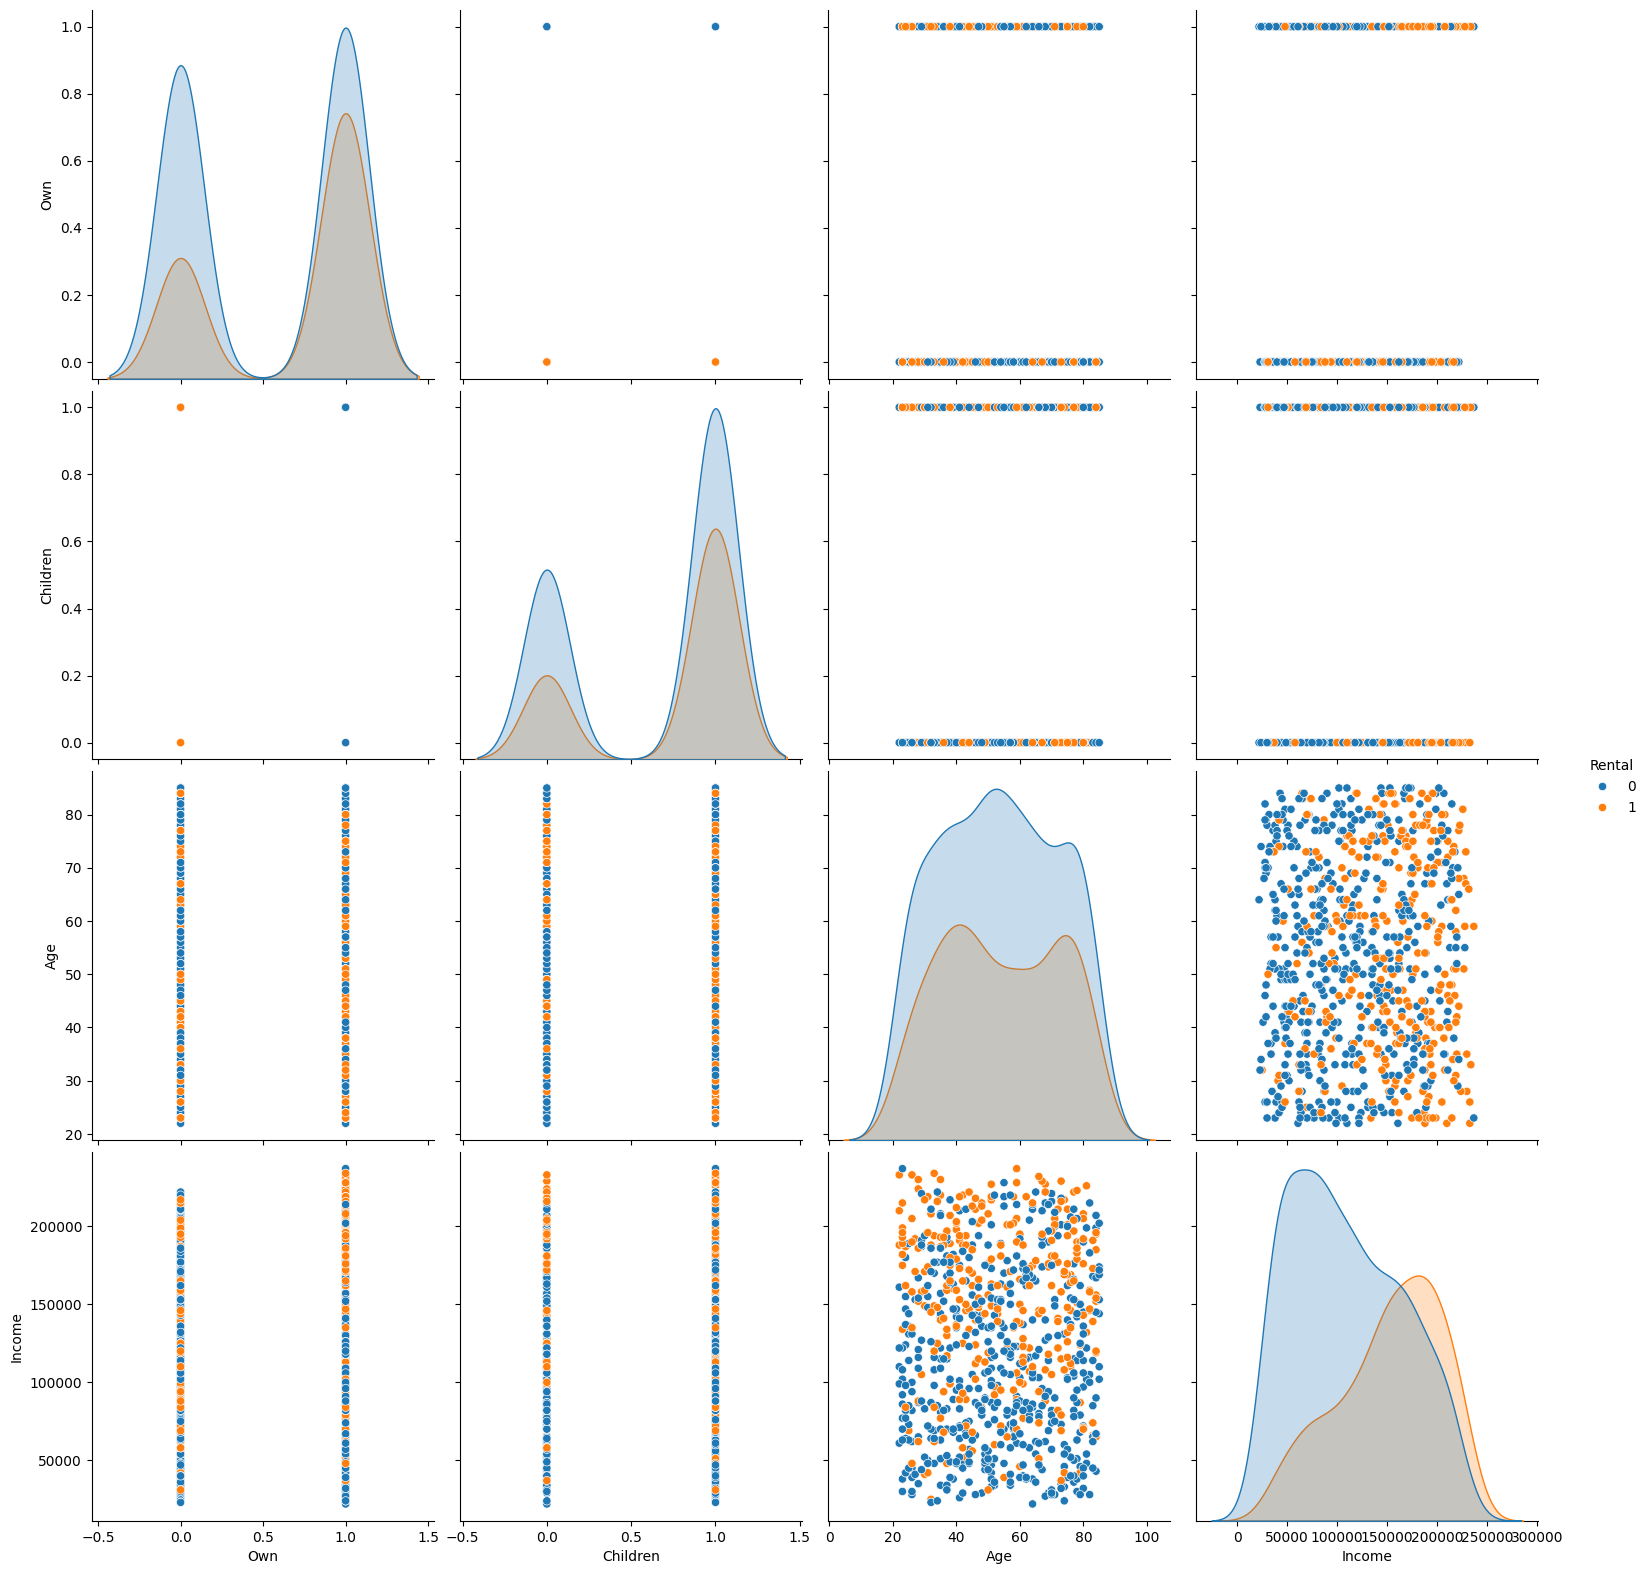

In [ ]:
import seaborn as sns
sns.pairplot(AAA, hue='Rental', size=4, vars=['Own','Children', 'Age', 'Income'])

###Describir lo que significan para el problema de negocio, cada una de las variables que hacen parte de la base de datos:
* **Own:** está variable binaria sirve para indicar si el individuo posee o no casa propia, en donde 1 indica que si la posee y 0 indica que no. Su importancia radica en que con está se puede saber cuales son las probabilidades de cada persona de rentar o no; los que poseen una cosa es menos probable que renten, mientras los que no poseen tienen mayor probabilidad.
* **Children:** está variable binaria nos indica si el individuo tiene o no hijos, en donde 1 significa que si tiene y 0 que no. Está nos ayuda a analizar la probabilidad de renta debido a que las personas con hijos podrían llegar tener más probabilidad de rentar en las vacaciones pensando en el espacio para ellos.
* **Age:** está es una variable numérica que dice cuales son las edades de las personas en el dataset. Con está podemos hacernos una idea también de que personas van a rentar, ya que entre más joven sea la persona puede haber más probabilidad de que quiera recurrrir a una renta.
* **Income:** está es una variable numérica que indica en valor de dólares cuanto es el ingreso anual de los individuos del dataset. Esta variable es bastante importante ya que dependiendo entre más altos sean los ingresos del indviduo (mayor capacidad de gasto), indica si puede o no alquilar una casa para estas vacaciones.
* **Rental:** está es la variable que se quiere predecir según las otras variables. Esta es binaria, donde 1 indica que la persona si alquilará y 0 que no.

In [ ]:
XD = AAA[['Own','Children', 'Age', 'Income']]

In [ ]:
yd = Vacation['Rental'].dropna()

In [ ]:
yd.shape

(820,)

In [ ]:
import numpy as np
dfinf = pd.DataFrame(np.column_stack((XD,yd)))
dfinf.columns=['Own','Children', 'Age', 'Income','Rental']
mCorr = dfinf.corr()
mCorr

,Own,Children,Age,Income,Rental
Own,1.000000,0.042532,0.067497,0.040827,0.156361
Children,0.042532,1.000000,-0.039087,-0.028243,0.086952
Age,0.067497,-0.039087,1.000000,0.005616,0.017890
Income,0.040827,-0.028243,0.005616,1.000000,0.355934
Rental,0.156361,0.086952,0.017890,0.355934,1.000000


<Axes: >

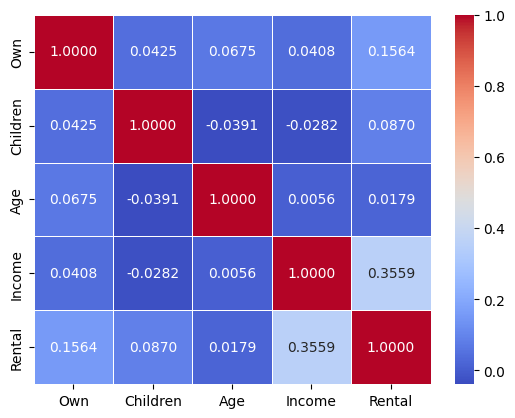

In [ ]:
sns.heatmap(mCorr, cmap='coolwarm', linewidth=0.5, annot=True, fmt='.4f')

###Determinar la variable que mejor lleva a cabo el proceso de caracterización del alquiler de los inmuebles.
R/= la variable que mejor lleva a cabo este proceso para caracterizar la renta es la variable de **income** ya que tiene una correlación más significativa con la variable para predecir (Rental).


###Según las variables de entrada y de salida, determinar cuáles variables tienen una mayor correlación entre ellas.
R/= Las variables que tienen más correlación entre ellas son **income y rental**, las cuales tienen una relación positiva moderada de 0.3559

In [ ]:
dfCorrel = pd.DataFrame(mCorr)
dfCorrel.to_excel('InformeCorrel.xlsx')

##Implementar modelo KNN

In [ ]:
XDArray = np.array(XD, dtype=float)
ydArray = np.array(yd, dtype=float)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knnModel = KNeighborsClassifier(n_neighbors=10)

In [ ]:
knnModel.fit(XDArray, ydArray)

KNeighborsClassifier(n_neighbors=10)

In [ ]:
ydPred = knnModel.predict(XDArray)
ydPred

##Métricas de evalución del modelo

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(ydArray, ydPred)

0.6415382466299662

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(ydArray, ydPred)
cm

array([[446,  67],
       [180, 127]])

###Determinar el comportamiento del modelo KNN en el pronóstico de los datos utilizados para la configuración del modelo en cuanto a exactitud, sensibilidad y especificidad.

In [ ]:
#Exactitud
print(f'La exactitud del modelos es del {(cm[1][1]+cm[0][0])/cm.sum():.2%}')

La exactitud del modelos es del 69.88%


La exactitud al ser de un 69.88% muestra que el modelo no tiene un rendimiento muy alto para predecir de forma correcta si hay más personas que rentan o no. Este predecería correctamente alrededor de 7 de cada 10 individuos.

In [ ]:
#Sensibilidad
print(f'La sensibilidad del modelo es del {cm[1][1]/(cm[1][1]+cm[1][0]):.2%}')

La sensibilidad del modelo es del 41.37%


La sensibilidad teniendo un valor de 41.37% es bastante bajo, en donde muestra que el modelo no está prediciendo los verdaderos positivos del modelo, osea las personas que si alquilaran estas vacaciones, por lo que el modelo está perdiendo más de la mitad de los ejemplos para identificar de forma correcta.

In [ ]:
#Especificidad
print(f'La especificidad del modelo es del {cm[0][0]/(cm[0][0]+cm[0][1]):.2%}')

La especificidad del modelo es del 86.94%


La especificidad al ser de 86.94%, indica que el modelo tiene un buen desempeño para predecir los verdaderos negativos, en este caso, las personas que no van a rentar casa estas vacaciones y que el modelo como se puede ver esta prediciendo correctamente en gran medida.

**Comportamiento del modelo:** según las métricas de exactitud, sensibilidad y especificidad, podmeos ver que el modelo tenía fortalezas a la hora de predecir correctamente en un gran nivel los ejemplos en donde las personas no van a rentar casa estas vacaciones gracias a su especificidad. Por otro lado el modelo si bien funciona de una forma relativamente buena según su exactitud de casi un 70%, aunque tiene un alto margen para mejorar.
También podemos identificar una gran debilidad que tiene el modelo con respecto a su sensibilidad, la cual tiene un valor bastante bajo indicando así que el modelo no es muy bueno prediciendo las personas que si van a rentar casa, lo cual es preocupante y sugiere así ajustar el modelo de otra forma o aplicar diferentes tecnicas para mejorarlo con respecto a una mejor identificación de los verdaderos positivos.

##Pronóstico

In [ ]:
XDGener = Vacation[Vacation['Rental'].isna()]
XDGener

,Own,Children,Age,Income,Rental


###Determinar si una persona con las siguientes características va a alquilar una casa esta temporada utilizando el modelo KNN
['Own', 'Children', 'Age', 'Income']= [(0, 0, 58, 83931)]



In [ ]:
XDi = np.array([(0, 0, 58, 83931)])
ydi = knnModel.predict(XDi)

print(f'La decisión frente a la renta es:{ydi}')

La decisión frente a la renta es:[0.]


####R/= Según el modelo KNN, el individuo analizado en el dataset no rentará una casa en estas vacaciones.

###De acuerdo con el individuo anterior, llevar a cabo su ubicación en la gráfica del modelo KNN teniendo en cuenta para ello las variables 'Age' vs 'Income'

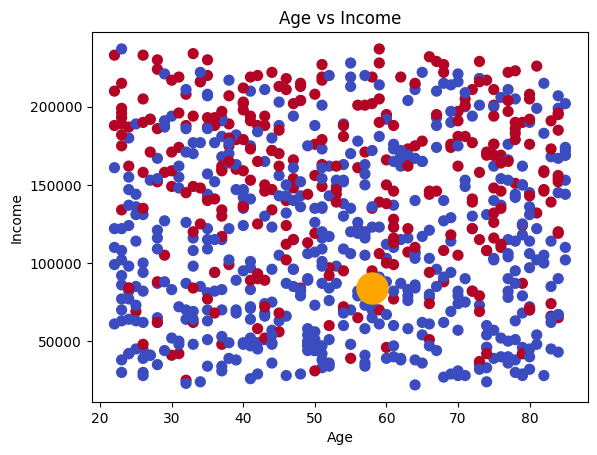

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(XDArray[:,2], XDArray[:,3], c=ydArray, s=50, cmap='coolwarm')
plt.scatter(XDi[:,2], XDi[:,3], marker='o', s=500, facecolor='orange')
plt.title('Age vs Income')
plt.xlabel('Age'); plt.ylabel('Income')
plt.show()

El cliente se encuentra en el punto naranja del gráfico con una edad de 58 y un ingreso de 83931, con este modelo se está comparando la situación de la persona con la de otros en el dataset teniendo en cuenta las variables previamente mencionadas.

Según el modelo KNN este cliente no rentará casa las próximas vacaciones.

#CLUSTERIZACIÓN CON KMEANS

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
## variable que aloja el modelo
np.random.seed(42)
## Cantidad de clusters que se crearan
k=5
kMeansModel = KMeans(n_clusters=k, init='random', random_state=42)

##Entrenar el modelo
kMeansModel.fit(XDArray, yd)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(init='random', n_clusters=5, random_state=42)

In [ ]:
#Analizar en que cluster se ubica uno de los solicitantes
labels = kMeansModel.labels_
centroids = kMeansModel.cluster_centers_

XDi = np.array([(0,0,58,83931)])
ydi = kMeansModel.predict(XDi)

print(f'Este solicitante de renta pertenece al cluster {ydi}')

Este solicitante de renta pertenece al cluster [1]


###De acuerdo con el individuo anterior, llevar a cabo su ubicación en la gráfica del modelo KMeans teniendo en cuenta para ello las variables 'Age' vs 'Income'

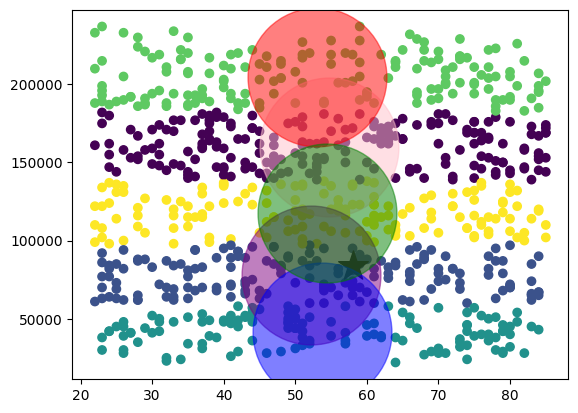

In [ ]:
plt.scatter(XDArray[:,2], XDArray[:,3], c=labels)
plt.scatter(XDi[:,2], XDi[:,3], marker='*', s=500, facecolor='black')
plt.scatter(centroids[0,2], centroids[0,3], marker='o', s=10000, alpha=0.5, facecolor='pink')
plt.scatter(centroids[1,2], centroids[1,3], marker='o', s=10000, alpha=0.5, facecolor='purple')
plt.scatter(centroids[2,2], centroids[2,3], marker='o', s=10000, alpha=0.5, facecolor='blue')
plt.scatter(centroids[3,2], centroids[3,3], marker='o', s=10000, alpha=0.5, facecolor='red')
plt.scatter(centroids[4,2], centroids[4,3], marker='o', s=10000, alpha=0.5, facecolor='green')

Cada cluster en este gráfico muestra la relación entre las variables de age e income. El cliente que se está evaluando lo agrupó el modelo KMeans en el cluster verde, por lo que indica qu esta dentro del grupo de personas en el dataset con ingresos de casi 100.000 dolares y edades entre los 50 hasta los 60 años, esto puede ser util para analizar la decisión del cliente de si alquilar o no.

In [ ]:
centroids

array([[6.11111111e-01, 6.41414141e-01, 5.46414141e+01, 1.60146465e+05],
       [5.48192771e-01, 7.04819277e-01, 5.21626506e+01, 7.79518072e+04],
       [5.76923077e-01, 7.30769231e-01, 5.37307692e+01, 4.17769231e+04],
       [6.09467456e-01, 7.10059172e-01, 5.30118343e+01, 2.04828402e+05],
       [5.85987261e-01, 6.30573248e-01, 5.43821656e+01, 1.17707006e+05]])

In [ ]:
AAA.loc[:,'cluster'] = labels

counts_1 = np.bincount(labels)
count_2 = AAA.groupby('cluster').agg({'Rental': lambda x:(x==0).sum()})
count_3 = AAA.groupby('cluster').agg({'Rental': lambda x:(x==1).sum()})

df = pd.DataFrame(np.column_stack((count_2, count_3 )))
df

,0,1
0,99,99
1,127,39
2,113,17
3,66,103
4,108,49


##Determinar el número de individuos que rentarán una casa esta temporada de acuerdo con la estructura de cada uno de los clústeres.
R/=
* **Según la estructura del cluster 1 con indice 0:** 99 clientes rentarán casa esta temporada.
* **Según la estructura del cluster 2 con indice 1:** 39 clientes rentarán casa esta temporada.
* **Según la estructura del cluster 3 con indice 2:** 17 clientes rentarán casa esta temporada.
* **Según la estructura del cluster 4 con indice 3:** 103 clientes rentarán casa esta temporada.
* **Según la estructura del cluster 5 con indice 4:** 49 clientes rentarán casa esta temporada.

In [ ]:
AAA[AAA['cluster']==0][['Own','Children', 'Age', 'Income']].describe()

,Own,Children,Age,Income
count,198.000000,198.000000,198.000000,198.000000
mean,0.611111,0.641414,54.641414,160146.464646
std,0.488734,0.480801,18.190411,12594.163608
min,0.000000,0.000000,22.000000,139000.000000
25%,0.000000,0.000000,39.000000,149000.000000
50%,1.000000,1.000000,53.000000,161500.000000
75%,1.000000,1.000000,71.000000,171000.000000
max,1.000000,1.000000,85.000000,182000.000000


###Indica cual es el clúster que presenta la menor cantidad de propietarios, la mayor cantidad de clientes con hijos, la mayor edad promedio y los mayores ingresos:


In [ ]:
AAA.groupby(['cluster'])['Own'].mean()

,Own
cluster,
0,0.611111
1,0.548193
2,0.576923
3,0.609467
4,0.585987


### **Cluster con menor cantidad de propietarios**: cluster 2 con indice 1

In [ ]:
AAA.groupby(['cluster'])['Children'].mean()

,Children
cluster,
0,0.641414
1,0.704819
2,0.730769
3,0.710059
4,0.630573


## **Cluster con mayor cantidad de clientes con hijos:** cluster 3 con indice 2

In [ ]:
#Promedios de las varibles de cada cluster comparados
AAA.groupby(['cluster'])['Age'].mean()

,Age
cluster,
0,54.641414
1,52.162651
2,53.730769
3,53.011834
4,54.382166


##**Cluster con mayor edad promedio:** cluster 1 con indice 0

In [ ]:
AAA.groupby(['cluster'])['Income'].mean()

,Income
cluster,
0,160146.464646
1,77951.807229
2,41776.923077
3,204828.402367
4,117707.006369


##**Cluster con mayores ingresos:** cluster 4 con indice 3

In [ ]:
#Promedio de edad e ingreso para los PreApr
AAA[AAA['Rental']==0].groupby(['cluster']).agg({'Own':'mean', 'Children':'mean', 'Age':'mean', 'Income':'mean'})

,Own,Children,Age,Income
cluster,,,,
0,0.484848,0.575758,53.454545,159868.686869
1,0.559055,0.637795,51.645669,77685.039370
2,0.557522,0.734513,54.150442,41415.929204
3,0.439394,0.696970,55.439394,203484.848485
4,0.555556,0.611111,53.175926,116870.370370
